In [69]:
################################################################################
# IMPORT LIBRARIES
################################################################################

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner

# import seaborn as sns
# sns.set_style('darkgrid')

#from matplotlib import rc
#rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
#rc('text', usetex=True)

# %matplotlib inline
# %config InlineBackend.figure_format='retina' # very useful command for high-res images

In [71]:
################################################################################
# SET PATHS
################################################################################

#folder_number = 'RESULT/result_SPEWie4.3_BATSE/norm_exp_relax_fast_v2'
folder_number = 'RESULT/result_SPEWie4.3_swift_rest_frame_lomax_renorm_poly_bpl/norm_exp_relax_fast_v1-N1000/'
#folder_number = 'RESULT/result_SPEWie4.3_fermi_rest_frame_lomax_renorm_poly/norm_exp_relax_fast_cube_corrected_v5-N1000-2ndtry'
file_path     = '/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/datafile.txt'
info_path     = '/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/simulation_info.txt'
csv_path_all  = '/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/df_all_gen.csv' 

with open(info_path) as f:
    for line in f:
        if line.startswith("sol_per_pop"):
            sol_per_pop = int(line.split()[-1])
            print('sol_per_pop      =', sol_per_pop)
        elif line.startswith("* Best fitness value reached after"):
            gen_best_fitness = int(line.split()[-2])
            print('gen_best_fitness =', gen_best_fitness)
        elif line.startswith("num_generations"):
            num_generations = int(line.split()[-1])
            print('num_generations  =', num_generations)

num_generations  = 60
sol_per_pop      = 1000
gen_best_fitness = 57


# 1. Plot Fitness

In [72]:
################################################################################
# LOAD DATA
################################################################################

generation = []
best_loss  = []
avg_loss   = []	 
std_loss   = []	 
std_loss_div_sqrt_sol_per_pop = [] 

with open(file_path, 'r') as result_file:
    result_file.readline()
    for line in result_file:
        line_split = line.split()
        generation.append( float(line_split[0]) )
        best_loss.append( float(line_split[1]) )
        avg_loss.append( float(line_split[2]) )
        std_loss.append( float(line_split[3]) )
        std_loss_div_sqrt_sol_per_pop.append( float(line_split[4]) )

In [73]:
print('Train best loss:          ', np.min(best_loss))
print('Train avg loss (last gen):', avg_loss[-1])

Train best loss:           0.6934822266066268
Train avg loss (last gen): nan


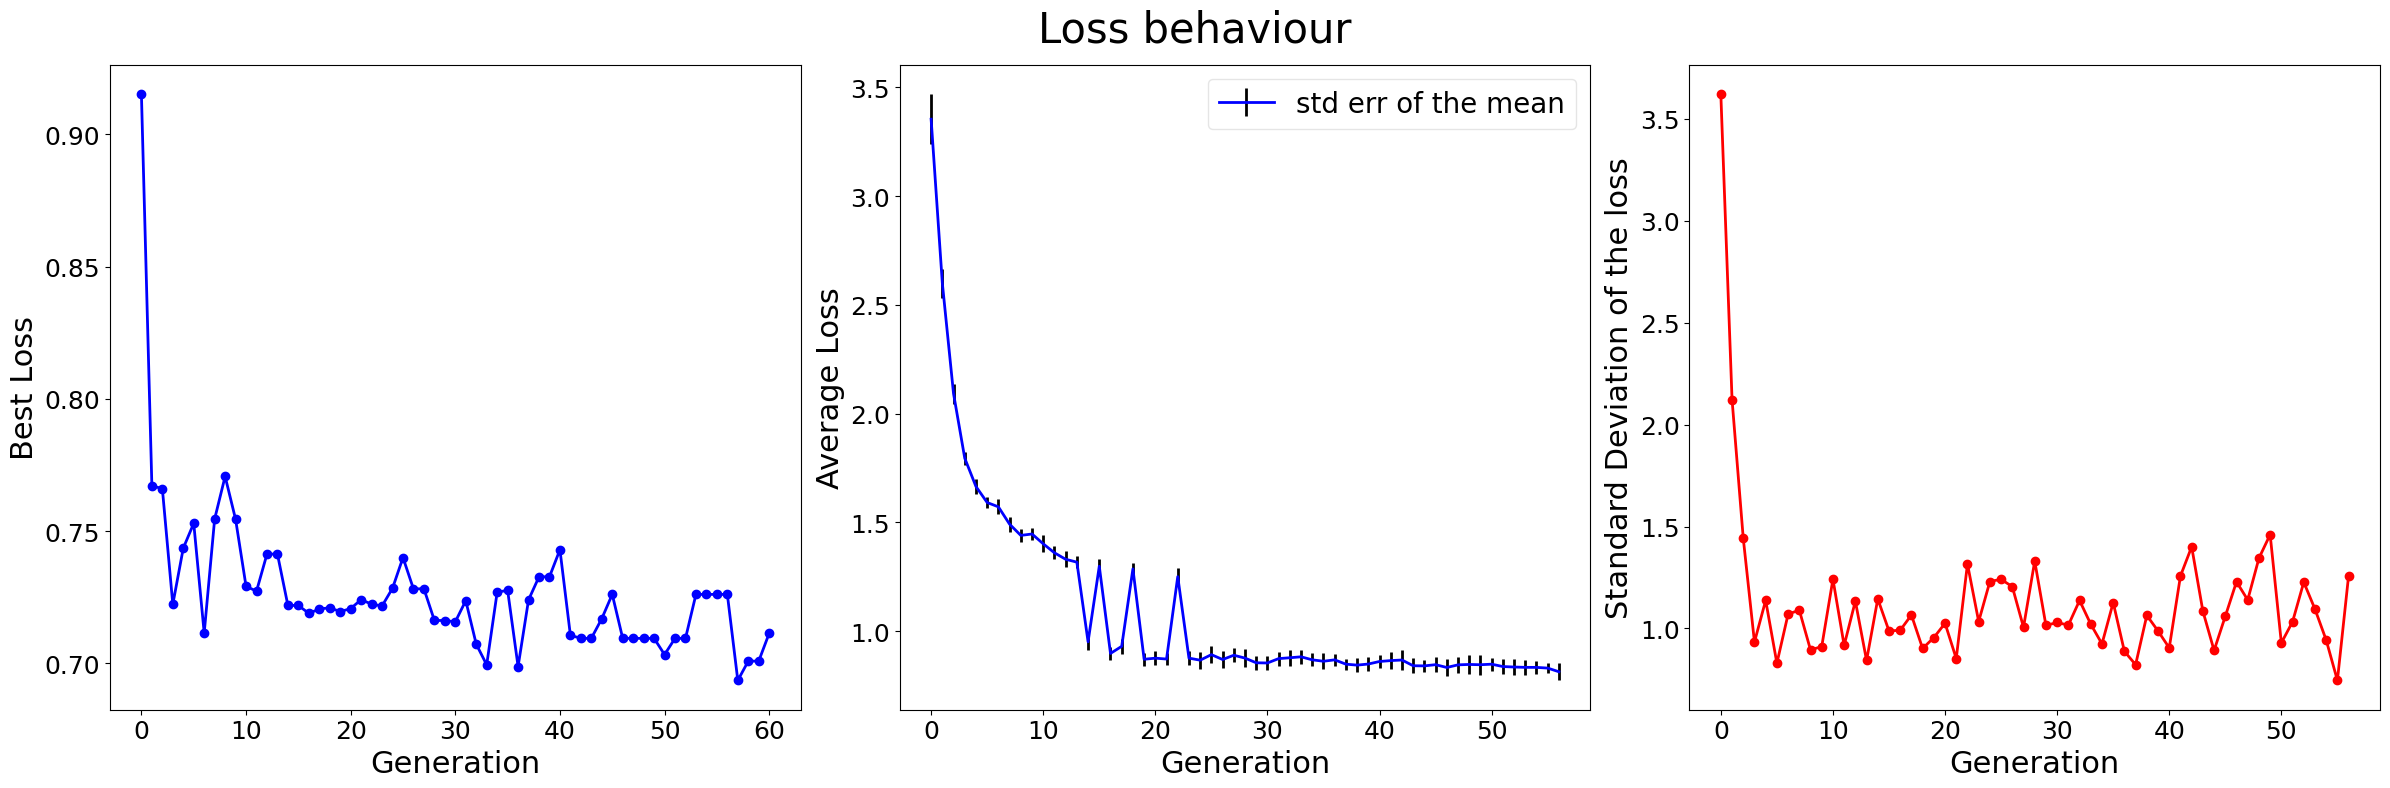

In [74]:
fig, ax = plt.subplots(1, 3, figsize=(24,8))   
################################################################################
# PLOT 1
################################################################################
ax[0].plot(best_loss, ls='-', lw=2, marker='o', c='b')
#plt.set)yscale('log')
ax[0].set_xlabel(r'Generation', size=22)
ax[0].set_ylabel(r'Best Loss',  size=22)
#ax[0].set_aspect('equal')
#ax[0].legend(prop={"size":20}, facecolor='white', framealpha=0.5)
################################################################################
# PLOT 2
################################################################################

#avg_loss = np.array([3.755,3.755, 3.297, 3.102, 2.986, 2.937, 2.915, 2.904, 2.896, 2.889, 2.883, 2.877, 2.873, 2.867, 2.861, 2.857, 2.852, 2.848, 2.845, 2.842, 2.838, 2.835, 2.830, 2.826, 2.824, 2.821, 2.819, 2.817, 2.815, 2.813, 2.813])
#std_loss = 0.05*avg_loss
#ax[1].errorbar(generation, avg_loss, yerr=std_loss,                      ls='-', lw=2, c='r', ecolor='r', alpha=0.5, label='std err')
ax[1].errorbar(generation, avg_loss, yerr=std_loss_div_sqrt_sol_per_pop, ls='-', lw=2, c='b', ecolor='k', alpha=1.0, label='std err of the mean')
#ax[1].yscale('log')
ax[1].set_xlabel(r'Generation',   size=22)
ax[1].set_ylabel(r'Average Loss', size=22)
#ax[1].set_ylim(1.5, 5)
ax[1].legend(prop={"size":20}, facecolor='white', framealpha=0.5)
################################################################################
# PLOT 3
################################################################################
ax[2].plot(std_loss, ls='-', lw=2, marker='o', c='r')
#ax[2].yscale('log')
ax[2].set_xlabel(r'Generation',                     size=22)
ax[2].set_ylabel(r'Standard Deviation of the loss', size=22)
#ax[2].legend(prop={"size":16}, facecolor='white', framealpha=0.5)
################################################################################
for axx in ax:
    axx.tick_params(axis='both', which='major', labelsize=18)  # Change tick font size
#fig.suptitle('Loss behaviour for v'+str(folder_number), size=30)
fig.suptitle('Loss behaviour', size=30)
fig.tight_layout()
plt.savefig('/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/fig-loss.pdf')
plt.show()

In [75]:
import re
import pandas as pd


def parse_generation_file(file_path):
    data_list = []
    current_gen = None
    current_data = {}

    # Regex to match the generation header (e.g., ###Generation = 1)
    gen_pattern = re.compile(r"###Generation\s*=\s*(\d+)")

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Check for a new generation block
            gen_match = gen_pattern.match(line)
            if gen_match:
                # If we already have data from a previous generation, save it
                if current_gen is not None and current_data:
                    current_data["Generation"] = int(current_gen)
                    data_list.append(current_data)

                # Reset for the new generation
                current_gen = gen_match.group(1)
                current_data = {}
                continue

            # Skip the closing '###' lines
            if line == "###":
                continue

            # Parse key-value pairs (e.g., tau_i = 0.977)
            if "=" in line:
                key, val = line.split("=", 1)
                key = key.strip()
                val = val.strip()

                try:
                    # Convert to float (handles standard floats and scientific notation)
                    current_data[key] = float(val)
                except ValueError:
                    # Fallback to string if it's not a number
                    current_data[key] = val

        # Don't forget to append the very last generation block
        if current_gen is not None and current_data:
            current_data["Generation"] = int(current_gen)
            data_list.append(current_data)

    # Convert the list of dictionaries into a clean Pandas DataFrame
    df = pd.DataFrame(data_list)

    # Move 'Generation' column to the front for readability
    if "Generation" in df.columns:
        cols = ["Generation"] + [
            col for col in df.columns if col != "Generation"
        ]
        df = df[cols]

    return df


# --- How to use it ---
# Replace 'data.txt' with the actual path to your file
file_name =  '/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+ folder_number + "/median_best_par_per_epoch.txt"

try:
    df = parse_generation_file(file_name)

    print("--- Parsed DataFrame ---")
    print(df.to_string(index=False))

    # Optional: Save the clean data to a CSV file
    # df.to_csv('generations_output.csv', index=False)

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")

--- Parsed DataFrame ---
 Generation  tau_i  tau_se  gamma     xi  alpha1           Lb  alpha2  Averaged Loss
          1  1.006   2.599  0.226 26.427   0.486 9.420000e+51   2.311          4.808
          2  1.282   2.599  0.256 31.801   0.408 1.355000e+52   2.432          3.035
          3  1.525   2.147  0.244 33.237   0.403 1.902000e+52   2.528          2.337
          4  1.525   2.147  0.256 33.237   0.406 1.922000e+52   2.237          1.902
          5  1.525   2.812  0.256 35.121   0.425 2.034000e+52   2.228          1.703
          6  1.583   2.831  0.269 32.968   0.449 2.034000e+52   2.170          1.671
          7  1.583   2.688  0.226 33.624   0.462 1.902000e+52   2.146          1.614
          8  1.583   2.688  0.222 33.728   0.486 1.902000e+52   2.146          1.593
          9  1.583   2.589  0.222 35.183   0.486 1.902000e+52   2.158          1.501
         10  1.583   2.831  0.217 36.082   0.486 1.789000e+52   2.146          1.457
         11  1.583   2.831  0.221 36.082

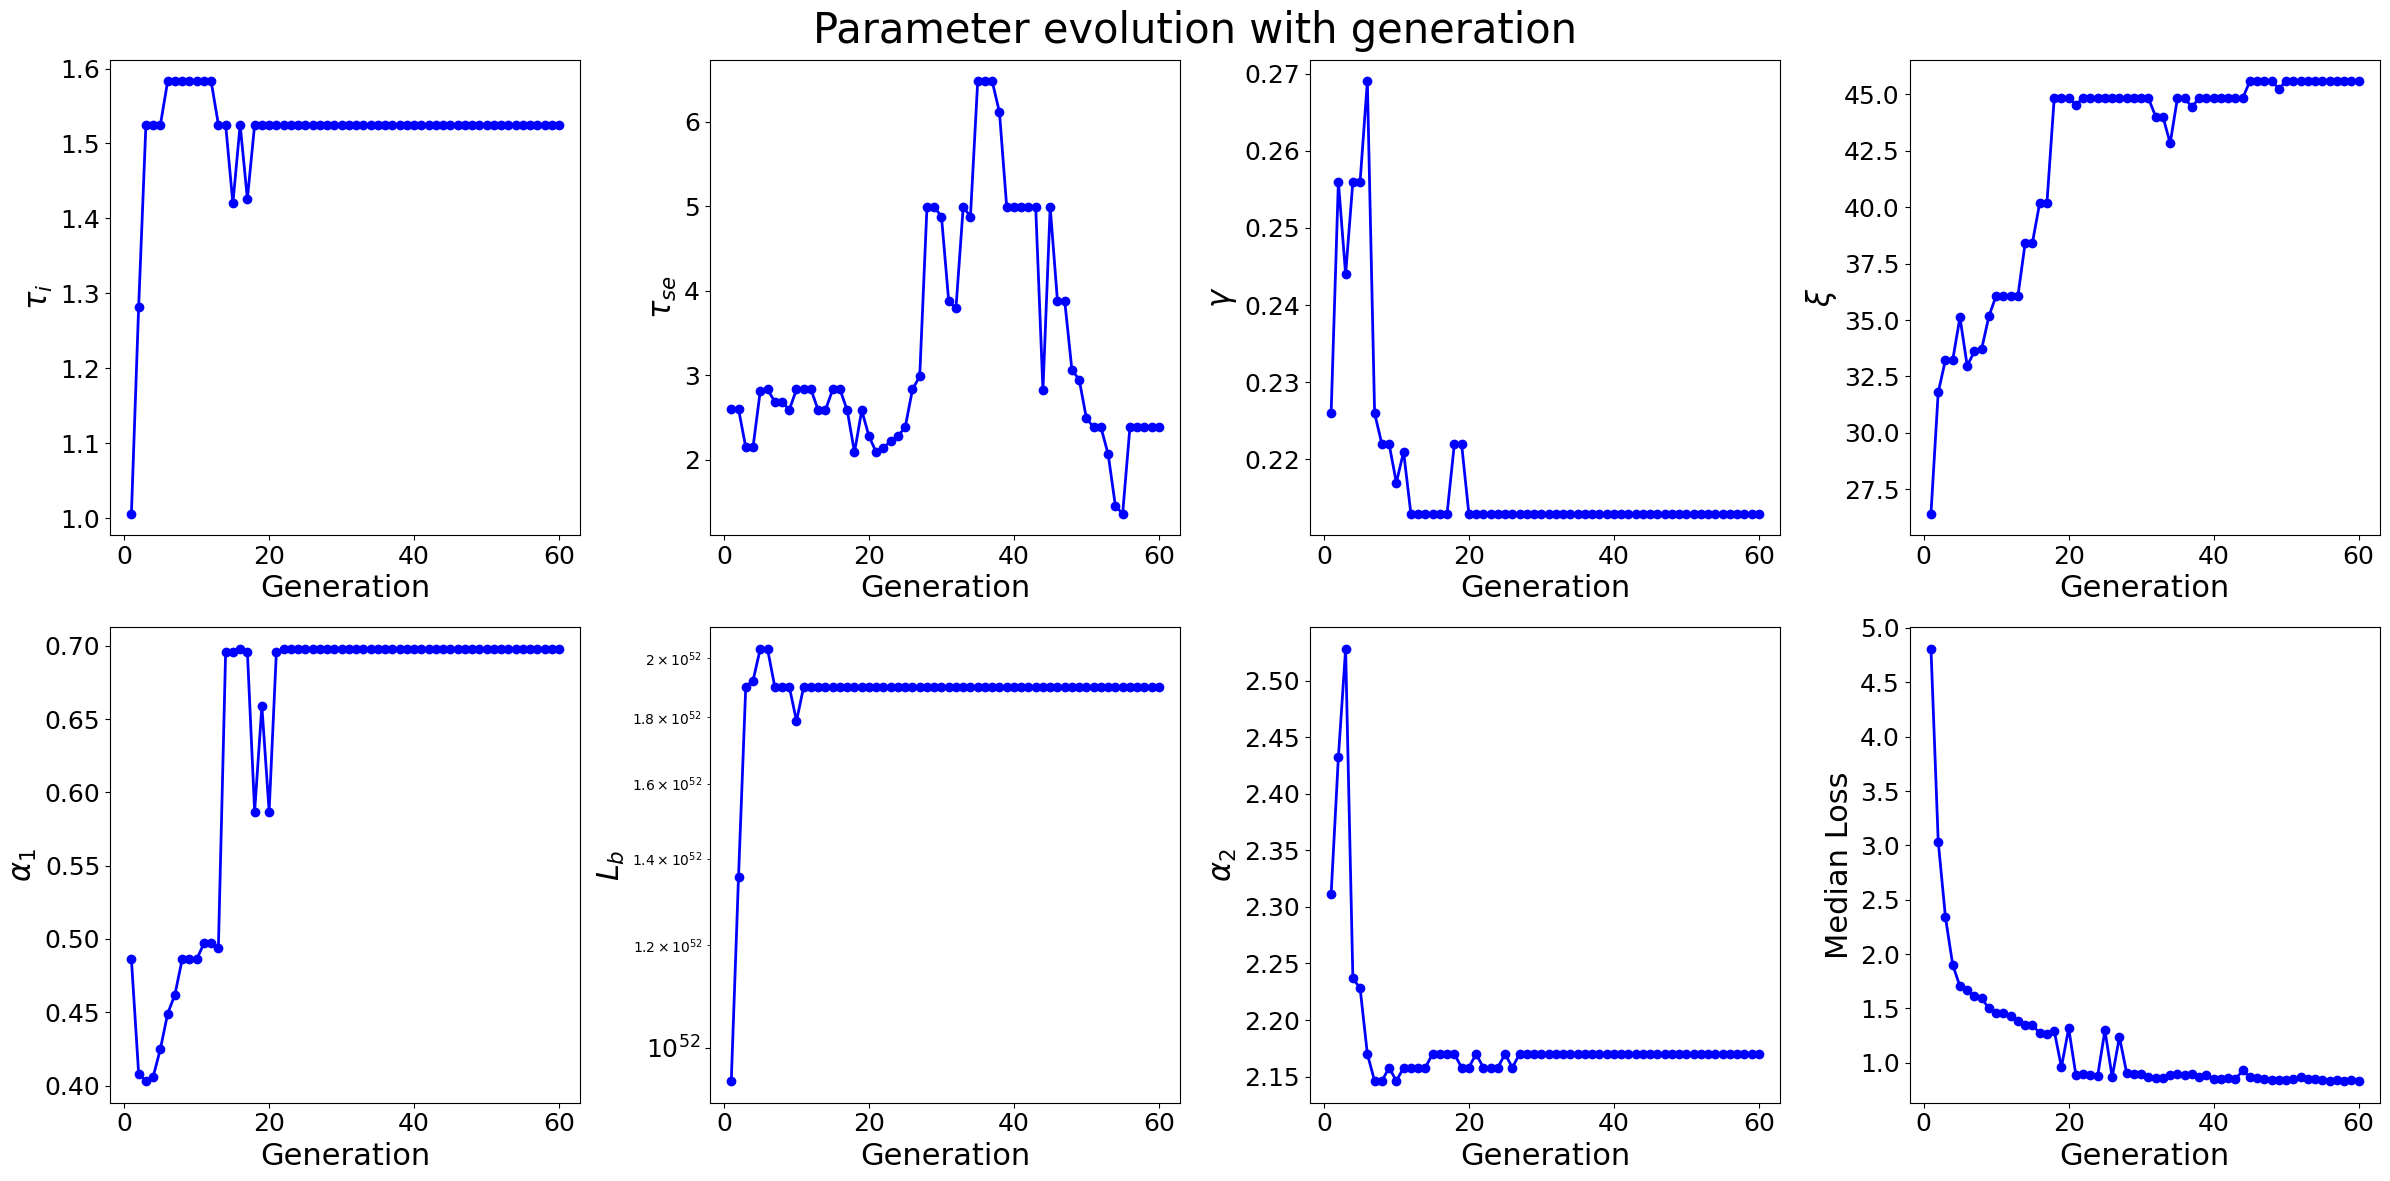

In [76]:
# make a plot with parameter evolution with generation for tau_i, tau_r, tau_se, gamma, delta, epsilon, x_e, alpha
fig, ax = plt.subplots(2, 4, figsize=(24,12))
ax[0,0].plot(df['Generation'], df['tau_i'], ls='-', lw=2, marker='o', c='b')
ax[0,0].set_xlabel(r'Generation', size=22)
ax[0,0].set_ylabel(r'$\tau_i$',  size=22)
ax[0,1].plot(df['Generation'], df['tau_se'], ls='-', lw=2, marker='o', c='b')
ax[0,1].set_xlabel(r'Generation', size=22)
ax[0,1].set_ylabel(r'$\tau_{se}$',  size=22)
ax[0,2].plot(df['Generation'], df['gamma'], ls='-', lw=2, marker='o', c='b')
ax[0,2].set_xlabel(r'Generation', size=22)
ax[0,2].set_ylabel(r'$\gamma$',  size=22)
ax[0,3].plot(df['Generation'], df['xi'], ls='-', lw=2, marker='o', c='b')
ax[0,3].set_xlabel(r'Generation', size=22)
ax[0,3].set_ylabel(r'$\xi$',  size=22)
ax[1,0].plot(df['Generation'], df['alpha1'], ls='-', lw=2, marker='o', c='b')
ax[1,0].set_xlabel(r'Generation', size=22)
ax[1,0].set_ylabel(r'$\alpha_1$',  size=22)
ax[1,1].plot(df['Generation'], df['Lb'], ls='-', lw=2, marker='o', c='b')
ax[1,1].set_xlabel(r'Generation', size=22)
ax[1,1].set_ylabel(r'$L_b$',  size=22)
ax[1,1].set_yscale('log')
ax[1,2].plot(df['Generation'], df['alpha2'], ls='-', lw=2, marker='o', c='b')
ax[1,2].set_xlabel(r'Generation', size=22)
ax[1,2].set_ylabel(r'$\alpha_2$',  size=22)

ax[1,3].plot(df['Generation'], df['Averaged Loss'], ls='-', lw=2, marker='o', c='b')
ax[1,3].set_xlabel(r'Generation', size=22)
ax[1,3].set_ylabel(r'Median Loss',  size=22)
for axx in ax.flatten():
    axx.tick_params(axis='both', which='major', labelsize=18)  # Change tick font size
fig.suptitle('Parameter evolution with generation', size=30)
fig.tight_layout()

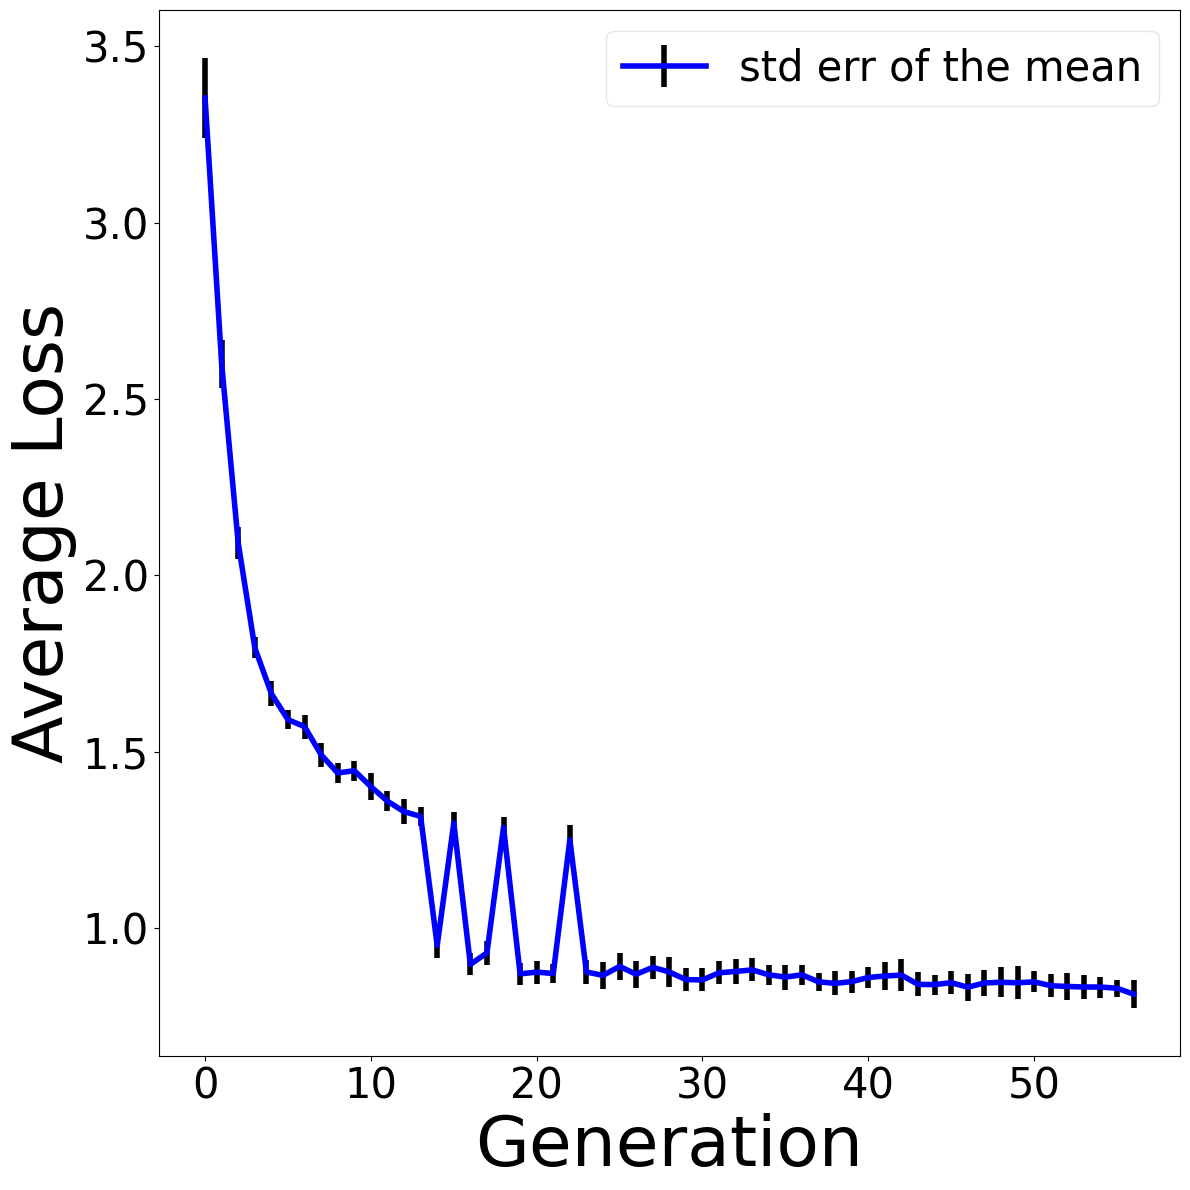

In [77]:
#std_loss_div_sqrt_sol_per_pop = 0.01*avg²a_loss
fig, ax = plt.subplots(1, 1, figsize=(12,12))   
################################################################################
#ax.errorbar(generation, avg_loss, yerr=std_loss,                      ls='-', lw=2, c='r', ecolor='r', alpha=0.5, label='std err')
ax.errorbar(generation, avg_loss, yerr=std_loss_div_sqrt_sol_per_pop, ls='-', lw=4, c='b', ecolor='k', alpha=1.0, label='std err of the mean')
#ax[0].yscale('log')
ax.set_xlabel(r'Generation',   size=50)
ax.set_ylabel(r'Average Loss', size=50)
ax.legend(prop={"size":30}, facecolor='white', framealpha=0.5)
ax.xaxis.set_tick_params(labelsize=30)
ax.yaxis.set_tick_params(labelsize=30)
################################################################################
fig.tight_layout()
plt.savefig('/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/fig-avg-loss.pdf')
plt.show()

In [78]:
# OLD
################################################################################
# MAKE PLOT
################################################################################

# plt.plot(best_loss, ls='-', lw=2, marker='o', c='b')
# #plt.yscale('log')
# plt.xlabel(r'Generation', size=14)
# plt.ylabel(r'Best Loss',  size=14)
# plt.savefig('./'+folder_number+'/_fig01.pdf')
# plt.show()
# 
# 
# plt.errorbar(generation, avg_loss, yerr=std_loss,                      ls='-', lw=2, c='r', ecolor='r', alpha=0.5, label='std err')
# plt.errorbar(generation, avg_loss, yerr=std_loss_div_sqrt_sol_per_pop, ls='-', lw=2, c='b', ecolor='k', alpha=1.0, label='std err of the mean')
# #plt.yscale('log')
# plt.xlabel(r'Generation',   size=14)
# plt.ylabel(r'Average Loss', size=14)
# plt.legend()
# plt.savefig('./'+folder_number+'/_fig02.pdf')
# plt.show()
# 
# 
# plt.plot(std_loss, ls='-', lw=2, marker='o', c='r')
# #plt.yscale('log')
# plt.xlabel(r'Generation',                     size=14)
# plt.ylabel(r'Standard Deviation of the loss', size=14)
# plt.savefig('./'+folder_number+'/_fig03.pdf')
# plt.show()

# 2. Plot Covariances

In [79]:
################################################################################
# LOAD DATA
################################################################################

df_all_gen = pd.read_csv(csv_path_all)
#all_gen   = df_all_gen.to_numpy()
#all_gen    = df_all_gen[['tau_i', 'tau_d', 'alpha', 'tau_se', 'x0', 'fitness']].to_numpy()
all_gen    = df_all_gen[['tau_i', 'tau_se','gamma','xi', 'alpha1','Lb','alpha2','fitness']].to_numpy()

print('shape(all_gen) =', np.shape(all_gen))


#---------
# ONLY FOR V25 OR BELOW
# all_gen[:,5] = 10**(all_gen[:,5])
#---------


#------------------------------------------------------------------------------#

zeroth_gen = all_gen[:sol_per_pop,:]
#print('shape(zeroth_gen) =', np.shape(zeroth_gen))
#------------------------------------------------------------------------------#

first_gen = all_gen[1*sol_per_pop:2*sol_per_pop,:] 
#print('shape(first_gen) =', np.shape(first_gen))
#------------------------------------------------------------------------------#

gen = 30
custom_gen = all_gen[gen*sol_per_pop:(gen+1)*sol_per_pop,:] 
#print('shape(custom_gen) =', np.shape(custom_gen))
#------------------------------------------------------------------------------#

#burn_in_gen    = 3
#no_burn_gen    = all_gen[burn_in_gen*sol_per_pop:,:] 
#random_samples = no_burn_gen[np.random.choice(no_burn_gen.shape[0], size=10000, replace=False)]
#print('shape(random_samples) =', np.shape(random_samples))
#------------------------------------------------------------------------------#

best_fitness_gen = all_gen[gen_best_fitness*sol_per_pop:(gen_best_fitness+1)*sol_per_pop,:] 
#print('shape(best_fitness_gen) =', np.shape(best_fitness_gen))
#------------------------------------------------------------------------------#

last_gen = all_gen[-sol_per_pop:,:]
#print('shape(last_gen) =', np.shape(last_gen))
#------------------------------------------------------------------------------#

shape(all_gen) = (61000, 8)


In [80]:
to_use = last_gen

median_values = np.median(to_use, axis=0)
lower_sigma   = median_values - np.percentile(to_use, 16, axis=0)
upper_sigma   = np.percentile(to_use, 84, axis=0) - median_values

print( np.round(median_values, 3) )
print( np.round(lower_sigma, 3) )
print( np.round(upper_sigma, 3) )

print('\ntau_i       =', np.round(np.median(to_use[:,0]),   3), '  ( + ', np.round(np.percentile(to_use[:,0],  84) - np.median(to_use[:,0]),   5), ', - ', np.round(np.median(to_use[:,0])  - np.percentile(to_use[:,0],  16),  5), ')')
print('tau_se    =',   np.round(np.median(to_use[:,1]),   2), '  ( + ', np.round(np.percentile(to_use[:,1],  84) - np.median(to_use[:,1]),   2), ', - ', np.round(np.median(to_use[:,1])  - np.percentile(to_use[:,1],  16),  2), ')')
print('gamma    =',   np.round(np.median(to_use[:,2]),   2), '  ( + ', np.round(np.percentile(to_use[:,2],  84) - np.median(to_use[:,2]),   2), ', - ', np.round(np.median(to_use[:,2])  - np.percentile(to_use[:,2],  16),  2), ')')
print('xi    =',   np.round(np.median(to_use[:,3]),   2), '  ( + ', np.round(np.percentile(to_use[:,3],  84) - np.median(to_use[:,3]),   2), ', - ', np.round(np.median(to_use[:,3])  - np.percentile(to_use[:,3],  16),  2), ')')
print('alpha1    =',   np.round(np.median(to_use[:,4]),   2), '  ( + ', np.round(np.percentile(to_use[:,4],  84) - np.median(to_use[:,4]),   2), ', - ', np.round(np.median(to_use[:,4])  - np.percentile(to_use[:,4],  16),  2), ')')
print('Lb    =',   np.round(np.median(to_use[:,5]),   2), '  ( + ', np.round(np.percentile(to_use[:,5],  84) - np.median(to_use[:,5]),   2), ', - ', np.round(np.median(to_use[:,5])  - np.percentile(to_use[:,5],  16),  2), ')')
print('alpha2    =',   np.round(np.median(to_use[:,6]),   2), '  ( + ', np.round(np.percentile(to_use[:,6],  84) - np.median(to_use[:,6]),   2), ', - ', np.round(np.median(to_use[:,6])  - np.percentile(to_use[:,6],  16),  2), ')')

# save the parameters in a file
# do it copilot
file=open('/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/best_parameters_avgd.txt','w')
file.write('tau_i       = '+str(np.round(np.median(to_use[:,0]),   3))+'  ( + '+str(np.round(np.percentile(to_use[:,0],  84) - np.median(to_use[:,0]),   4))+', - '+str(np.round(np.median(to_use[:,0])  - np.percentile(to_use[:,0],  16),  3))+')\n')
file.write('tau_se    = '+str(np.round(np.median(to_use[:,1]),   2))+'  ( + '+str(np.round(np.percentile(to_use[:,1],  84) - np.median(to_use[:,1]),   2))+', - '+str(np.round(np.median(to_use[:,1])  - np.percentile(to_use[:,1],  16),  2))+')\n')
file.write('gamma    = '+str(np.round(np.median(to_use[:,2]),   2))+'  ( + '+str(np.round(np.percentile(to_use[:,2],  84) - np.median(to_use[:,2]),   2))+', - '+str(np.round(np.median(to_use[:,2])  - np.percentile(to_use[:,2],  16),  2))+')\n')
file.write('xi    = '+str(np.round(np.median(to_use[:,3]),   2))+'  ( + '+str(np.round(np.percentile(to_use[:,3],  84) - np.median(to_use[:,3]),   2))+', - '+str(np.round(np.median(to_use[:,3])  - np.percentile(to_use[:,3],  16),  2))+')\n')
file.write('alpha1    = '+str(np.round(np.median(to_use[:,4]),   2))+'  ( + '+str(np.round(np.percentile(to_use[:,4],  84) - np.median(to_use[:,4]),   2))+', - '+str(np.round(np.median(to_use[:,4])  - np.percentile(to_use[:,4],  16),  2))+')\n')
file.write('Lb    = '+str(np.round(np.median(to_use[:,5]),   2))+'  ( + '+str(np.round(np.percentile(to_use[:,5],  84) - np.median(to_use[:,5]),   2))+', - '+str(np.round(np.median(to_use[:,5])  - np.percentile(to_use[:,5],  16),  2))+')\n')
file.write('alpha2    = '+str(np.round(np.median(to_use[:,6]),   2))+'  ( + '+str(np.round(np.percentile(to_use[:,6],  84) - np.median(to_use[:,6]),   2))+', - '+str(np.round(np.median(to_use[:,6])  - np.percentile(to_use[:,6],  16),  2))+')\n')
file.close()

[1.52500000e+00 2.38400000e+00 2.13000000e-01 4.55850000e+01
 6.98000000e-01 1.90184591e+52 2.17000000e+00 1.20200000e+00]
[0.    1.662 0.053 0.    0.    0.    0.    0.638]
[0.00000000e+00 3.73100000e+00 5.50000000e-02 1.76600000e+00
 0.00000000e+00 1.12762891e+51 0.00000000e+00 9.00000000e-02]

tau_i       = 1.525   ( +  0.0 , -  0.0 )
tau_se    = 2.38   ( +  3.73 , -  1.66 )
gamma    = 0.21   ( +  0.06 , -  0.05 )
xi    = 45.59   ( +  1.77 , -  0.0 )
alpha1    = 0.7   ( +  0.0 , -  0.0 )
Lb    = 1.9018459051328192e+52   ( +  1.1276289077077226e+51 , -  0.0 )
alpha2    = 2.17   ( +  0.0 , -  0.0 )


log_Lb       = 52.2792   ( +  -0.5807 , -  0.5807 )


(array([  3.,   3.,   3.,   3.,   1.,   3.,   3.,   2.,   1.,   5.,   1.,
          3.,   9.,   3.,   1., 789., 159.,   3.,   2.,   3.]),
 array([50.72766157, 50.82614402, 50.92462647, 51.02310892, 51.12159137,
        51.22007382, 51.31855627, 51.41703873, 51.51552118, 51.61400363,
        51.71248608, 51.81096853, 51.90945098, 52.00793343, 52.10641588,
        52.20489834, 52.30338079, 52.40186324, 52.50034569, 52.59882814,
        52.69731059]),
 <BarContainer object of 20 artists>)

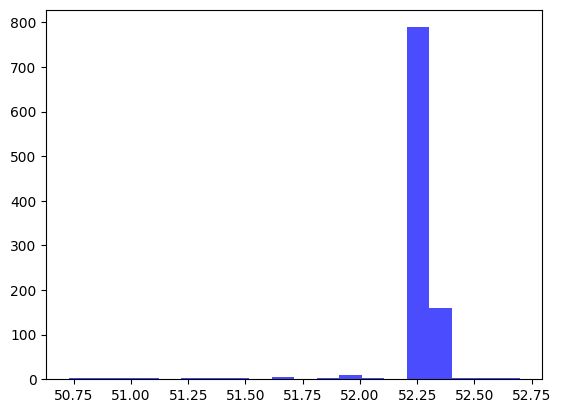

In [91]:
log_Lb = np.log10(to_use[:,5])
log_Lb_median = np.median(log_Lb)
log_Lb_lower_sigma = log_Lb_median - np.percentile(log_Lb, 2.5)
log_Lb_upper_sigma = np.percentile(log_Lb, 2.5) - log_Lb_median
print('log_Lb       =', np.round(log_Lb_median, 4), '  ( + ', np.round(log_Lb_upper_sigma, 4), ', - ', np.round(log_Lb_lower_sigma, 4), ')')

plt.hist(log_Lb, bins=20, color='blue', alpha=0.7)


In [90]:
tau_i_med = np.median(to_use[:,0])
tau_i_2_5 = np.percentile(to_use[:,0],  2.5)
tau_i_97_5 = np.percentile(to_use[:,0], 98)
print('\ntau_i 95% confidence interval = [', np.round(tau_i_2_5, 3), ', ', np.round(tau_i_97_5, 3), ']',np.round(np.median(to_use[:,0]), 3))

tau_se_med = np.median(to_use[:,1])
tau_se_2_5 = np.percentile(to_use[:,1],  2.5)
tau_se_97_5 = np.percentile(to_use[:,1], 97.5)
print('tau_se 95% confidence interval = [', np.round(tau_se_2_5, 2), ', ', np.round(tau_se_97_5, 2), ']',np.round(np.median(to_use[:,1]), 2))

gamma_med = np.median(to_use[:,2])
gamma_2_5 = np.percentile(to_use[:,2],  2.5)
gamma_97_5 = np.percentile(to_use[:,2], 97.5)
print('gamma 95% confidence interval = [', np.round(gamma_2_5, 2), ', ', np.round(gamma_97_5, 2), ']',np.round(np.median(to_use[:,2]), 2))

xi_med = np.median(to_use[:,3])
xi_2_5 = np.percentile(to_use[:,3],  2.5)
xi_97_5 = np.percentile(to_use[:,3], 97.5)
print('xi 95% confidence interval = [', np.round(xi_2_5, 2), ', ', np.round(xi_97_5, 2), ']',np.round(np.median(to_use[:,3]), 2))

alpha1_med = np.median(to_use[:,4])
alpha1_2_5 = np.percentile(to_use[:,4],  2.5)
alpha1_97_5 = np.percentile(to_use[:,4], 97.5)
print('alpha1 95% confidence interval = [', np.round(alpha1_2_5, 2), ', ', np.round(alpha1_97_5, 2), ']',np.round(np.median(to_use[:,4]), 2))

Lb_2_med = np.median(to_use[:,5])
Lb_2_5 = np.percentile(to_use[:,5],  1)
Lb_97_5 = np.percentile(to_use[:,5], 99)
print('Lb 95% confidence interval = [', np.round(Lb_2_5, 2), ', ', np.round(Lb_97_5, 2), ']',np.round(np.median(to_use[:,5]), 2))

alpha2_med = np.median(to_use[:,6])
alpha2_2_5 = np.percentile(to_use[:,6],  2.5)
alpha2_97_5 = np.percentile(to_use[:,6], 97.5)
print('alpha2 95% confidence interval = [', np.round(alpha2_2_5, 2), ', ', np.round(alpha2_97_5, 2), ']',np.round(np.median(to_use[:,6]), 2))

## make difference between median and lower and upper sigma in percentage
print(np.round(tau_i_med-tau_i_2_5,3), np.round(tau_i_med,3),np.round(tau_i_97_5-tau_i_med,3))
print(np.round(tau_se_med-tau_se_2_5,3),np.round(tau_se_med,3), np.round(tau_se_97_5-tau_se_med,3))
print(np.round(gamma_med-gamma_2_5,3),np.round(gamma_med,3) ,np.round(gamma_97_5-gamma_med,3))
print(np.round(xi_med-xi_2_5,3), np.round(xi_med,3), np.round(xi_97_5-xi_med,3))
print(np.round(alpha1_med-alpha1_2_5,3),np.round(alpha1_med,3), np.round(alpha1_97_5-alpha1_med,3))
print(np.round(Lb_2_med-Lb_2_5,3), np.round(Lb_2_med,3), np.round(Lb_97_5-Lb_2_med,3))
print(np.round(alpha2_med-alpha2_2_5,3), np.round(alpha2_med,3),  np.round(alpha2_97_5-alpha2_med,3))


tau_i 95% confidence interval = [ 0.732 ,  1.585 ] 1.525
tau_se 95% confidence interval = [ 0.68 ,  8.55 ] 2.38
gamma 95% confidence interval = [ 0.09 ,  0.36 ] 0.21
xi 95% confidence interval = [ 24.5 ,  48.86 ] 45.59
alpha1 95% confidence interval = [ 0.49 ,  1.13 ] 0.7
Lb 95% confidence interval = [ 1.2337216319753226e+51 ,  2.322832890077945e+52 ] 1.9018459051328192e+52
alpha2 95% confidence interval = [ 2.12 ,  3.09 ] 2.17
0.793 1.525 0.059
1.708 2.384 6.163
0.118 0.213 0.145
21.086 45.585 3.271
0.212 0.698 0.427
1.778473741935287e+52 1.9018459051328192e+52 4.209869849451258e+51
0.046 2.17 0.924


In [34]:
Lb_97_5,Lb_2_med

(2.758295457207333e+52, 2.3811619523996518e+52)

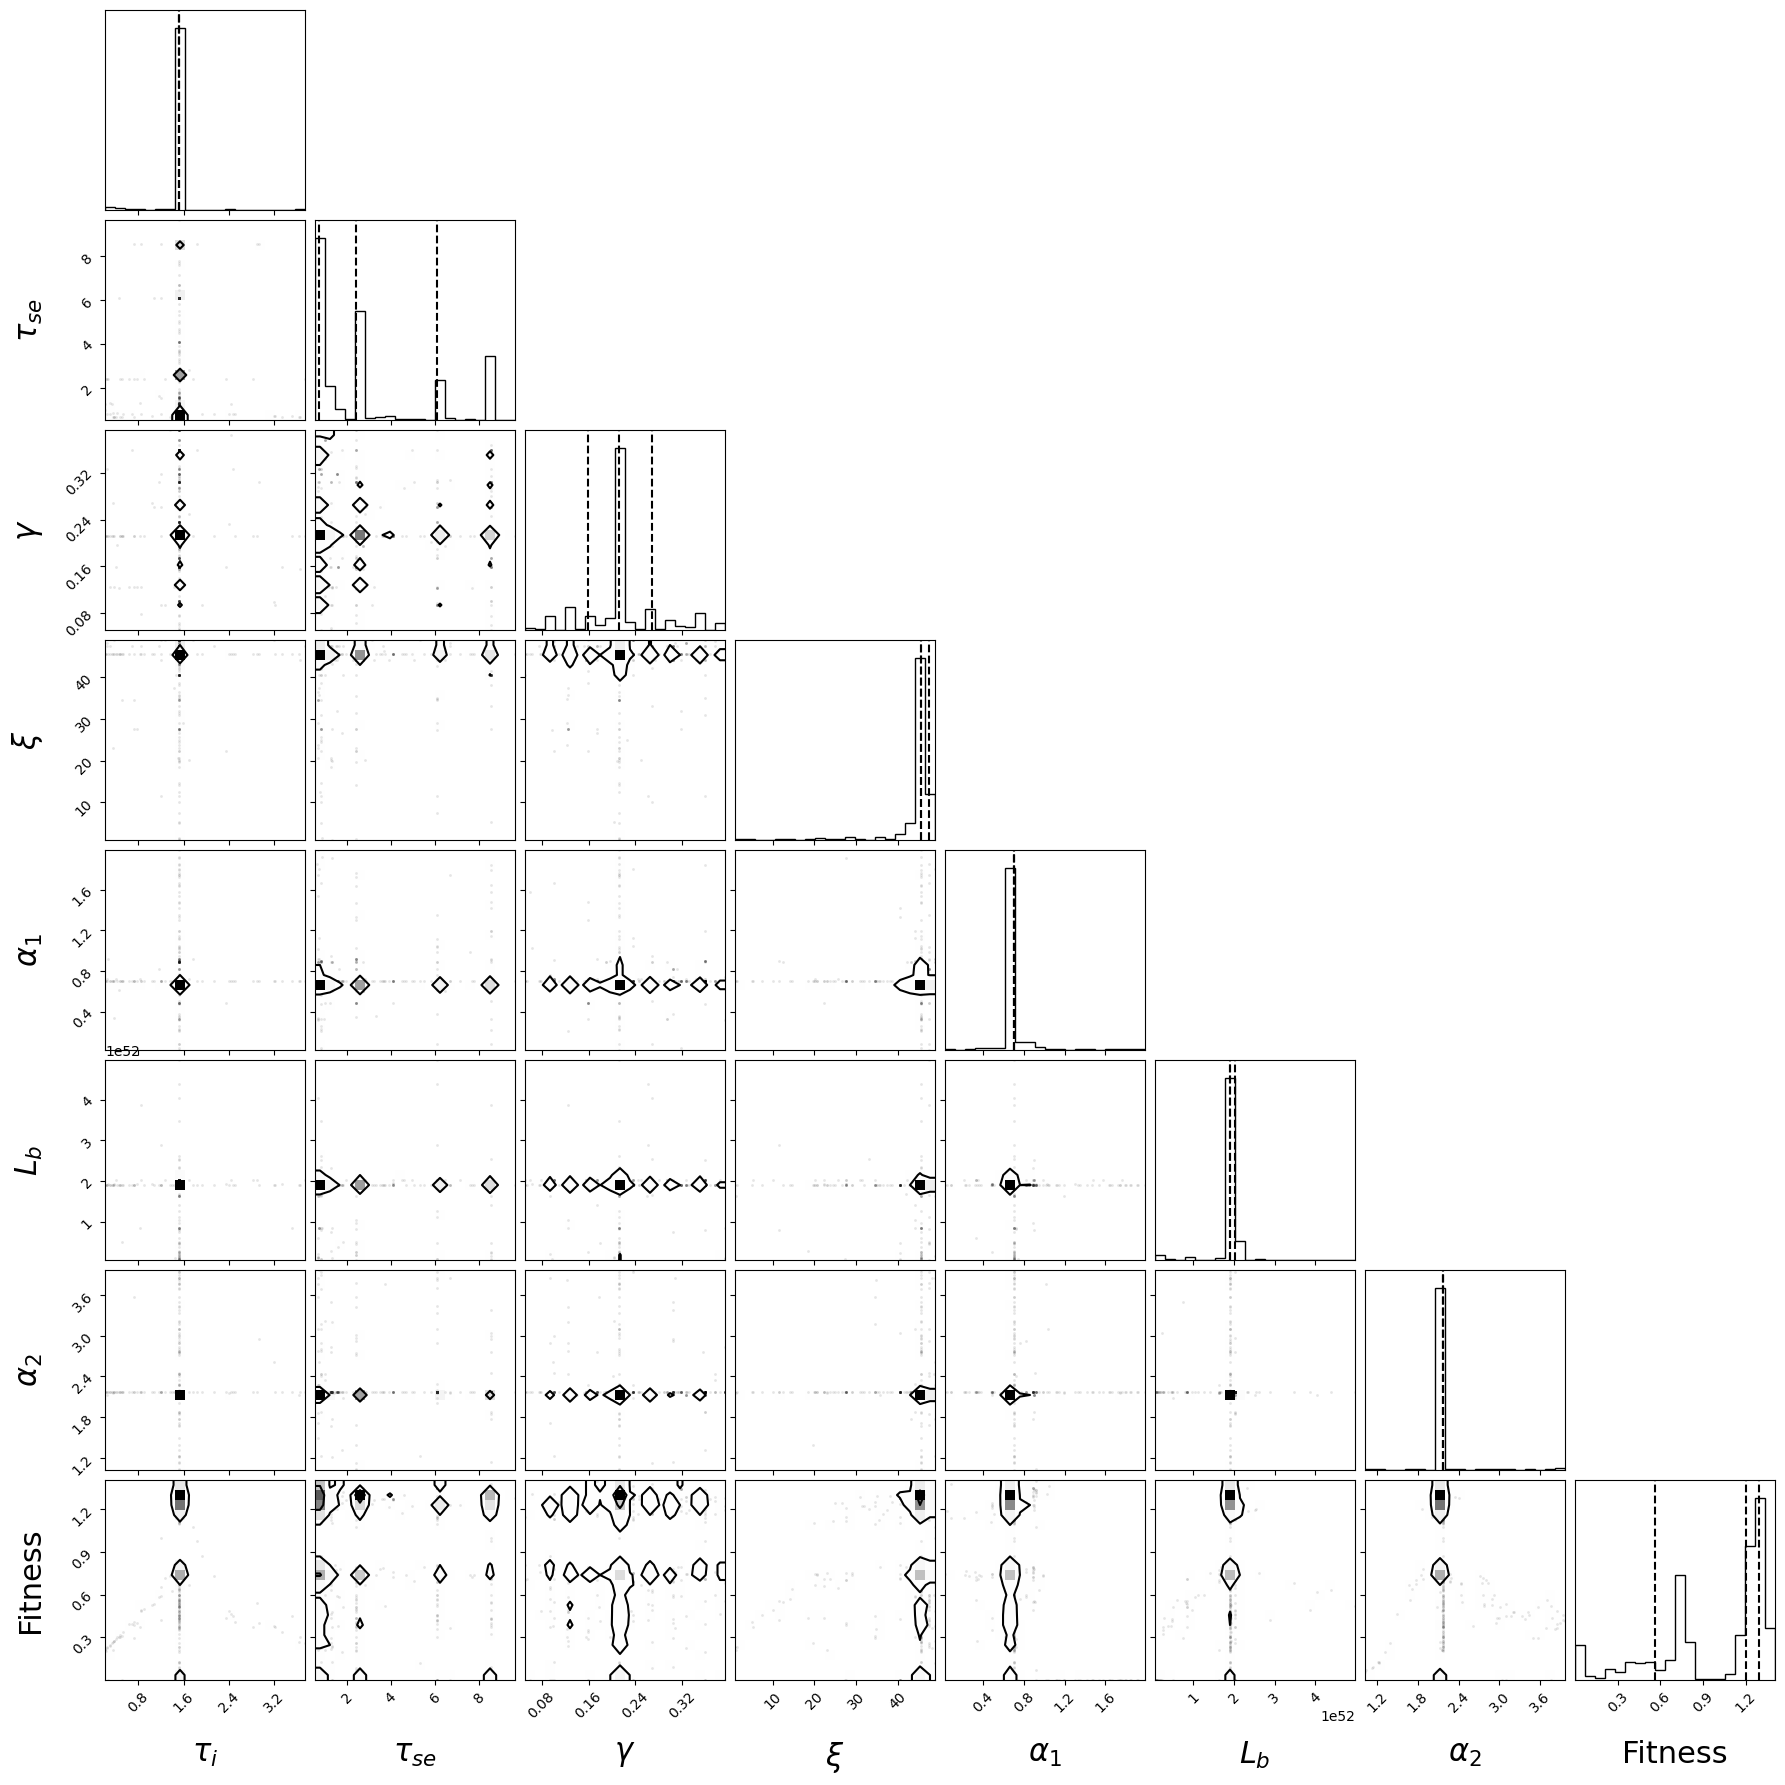

In [83]:
used_gen=last_gen

range_ = [(0.1, 10),(0.1,100),(0,0.6),(0.5,30),(4e52,6e52),(0,3),(1,2)]
#  (1.0028642693466656, 9.999944242708196),
#  (1.001801463133051, 3.9990039582207695),
#  (0.010097862052859, 99.74947391535476),
#  (103.4761025409377, 1e4),
#  (1.0003109875087564, 3.997283607546732),
#  (0, 0.3)]


#range_ = [(np.min(used_gen[:,i]),np.max(used_gen[:,i])) for i in range(6)]
# instead of the min and max, we can use the 16th and 84th percentile
#range_ = [(np.percentile(used_gen[:,i], 1),np.percentile(used_gen[:,i], 99)) for i in range(6)]
#range_= [(2.95,3.2),(7.5,8.5),(0.8,1.3),(1,10),(0.2,2.5),(0,1)]
#range_ = [0.95 for i in range(6)]
from matplotlib.colors import LogNorm

figure = corner.corner(
    used_gen,
    #all_gen,
    #zeroth_gen,
   # first_gen,
    #custom_gen,
    #random_samples,
    #best_fitness_gen,
    #last_gen,
    #to_use,
    labels=[
        r"$\tau_i$",
        r"$\tau_{se}$",
        r"$\gamma$",
        r"$\xi$",
        r"$\alpha_1$",
        r"$L_b$",
        r"$\alpha_2$",
        r"Fitness"
    ],
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.39, 0.86], # 1,2 sigmas 
    show_titles=False,
    fill_contours=False,
    smooth=0.1,
    #plot_density=False,
    #plot_datapoints=False,
    #show_titles=True,
    #max_n_ticks=3,
    #title_fmt=".2E",
    label_kwargs={"fontsize": 22},
    title_kwargs={"fontsize": 20},
   # range=range_
)
plt.savefig('corner_plot_bpl.pdf')
plt.show()

# 3. Plot Parameter time-behavior

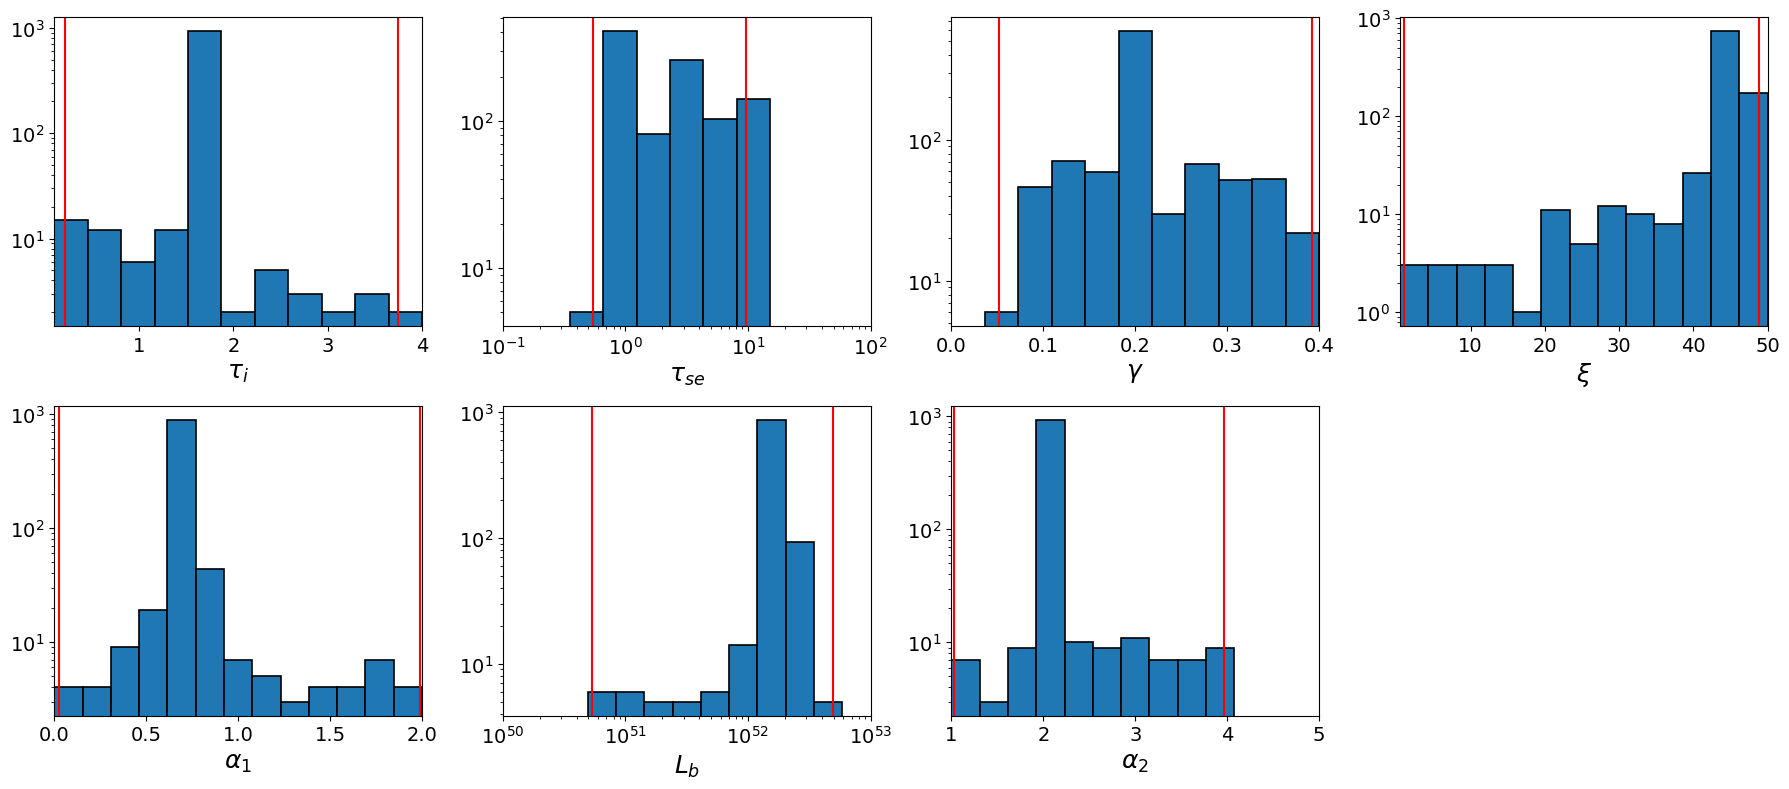

In [84]:
used_gen = last_gen

# Create multi-panel figure
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# tau_i
axes[0].hist(used_gen[:,0], bins=np.linspace(0.1,4, 12), edgecolor='black', linewidth=1.2)
axes[0].set_yscale('log')
axes[0].set_xlim(0.1, 4)
axes[0].set_xlabel(r'$\tau_i$', size=18)
axes[0].tick_params(axis='both', which='major', labelsize=14)


# tau_se
axes[1].hist(used_gen[:,1], bins=np.logspace(-1,2, 12), edgecolor='black', linewidth=1.2)
axes[1].set_xlim(0.1,100)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$\tau_{se}$', size=18)
axes[1].tick_params(axis='both', which='major', labelsize=14)

# gamma
axes[2].hist(used_gen[:,2], bins=np.linspace(0., 0.4, 12), edgecolor='black', linewidth=1.2)
axes[2].set_xlim(0, 0.4)
#axes[2].set_xscale('log')
axes[2].set_xlabel(r'$\gamma$', size=18)
axes[2].tick_params(axis='both', which='major', labelsize=14)


# xi
axes[3].hist(used_gen[:,3], bins=np.linspace(0.5, 50, 14), edgecolor='black', linewidth=1.2)
#axes[5].set_xscale('log')
axes[3].set_xlim(0.5, 50)
axes[3].set_xlabel(r'$\xi$', size=18)
axes[3].tick_params(axis='both', which='major', labelsize=14)

# alpha1
axes[4].hist(used_gen[:,4], bins=np.linspace(0,2, 14), edgecolor='black', linewidth=1.2)
axes[4].set_xlim(0, 2)
axes[4].set_xlabel(r'$\alpha_1$', size=18)
axes[4].tick_params(axis='both', which='major', labelsize=14)
# Lb
axes[5].hist(used_gen[:,5], bins=np.logspace(50,53, 14), edgecolor='black', linewidth=1.2)
axes[5].set_xlim(1e50, 1e53)
axes[5].set_xlabel(r'$L_b$', size=18)
axes[5].tick_params(axis='both', which='major', labelsize=14)
axes[5].set_yscale('log')
axes[5].set_xscale('log')

# alpha2
axes[6].hist(used_gen[:,6], bins=np.linspace(1,5, 14), edgecolor='black', linewidth=1.2)
axes[6].set_xlim(1, 5)
axes[6].set_xlabel(r'$\alpha_2$', size=18)
axes[6].tick_params(axis='both', which='major', labelsize=14)
# Hide unused subplots

for i in range(7, 8):
    axes[i].axis('off')
    axes[i].set_visible(False)

for i in range(7):
    axes[i].axvline(np.min(used_gen[:,i]), color='r', linestyle='-', label='min')
    axes[i].axvline(np.max(used_gen[:,i]), color='r', linestyle='-', label='max')
    axes[i].set_yscale('log')
plt.tight_layout()
plt.show()

(0.21737122117778257, 0.0626317655760849)

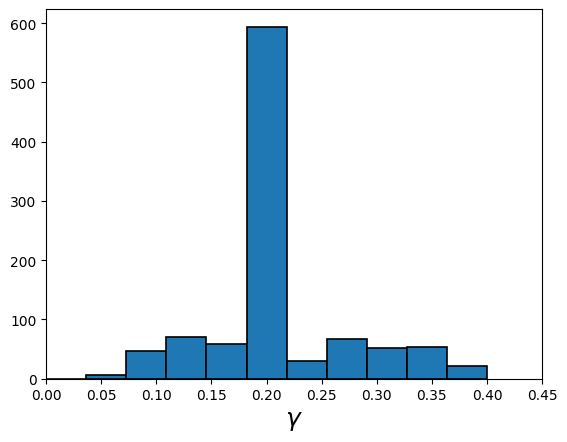

In [85]:
plt.hist(used_gen[:,2],bins=np.linspace(0., 0.4, 12), edgecolor='black', linewidth=1.2)
plt.xlabel(r'$\gamma$', size=18)
plt.xlim(0, 0.45)
np.median(used_gen[:,2]), np.percentile(used_gen[:,2], 16), np.percentile(used_gen[:,2], 84)
np.mean(used_gen[:,2]), np.std(used_gen[:,2])

KeyError: 'tau_d'

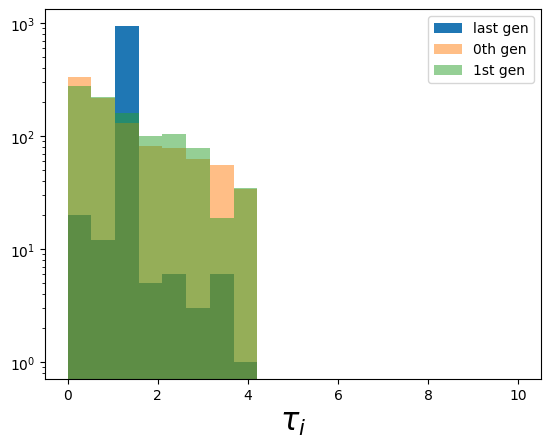

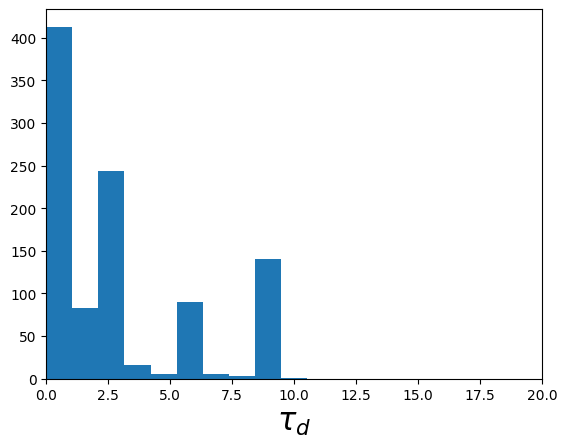

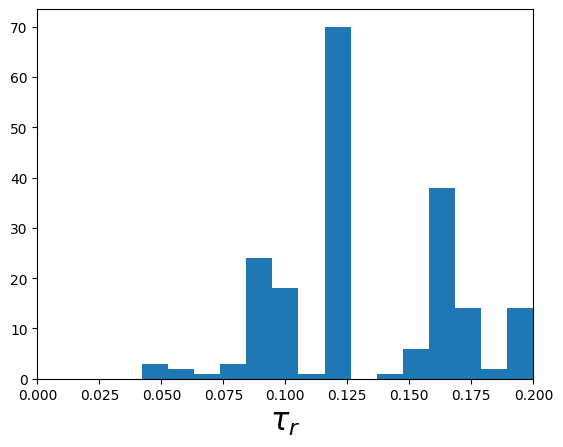

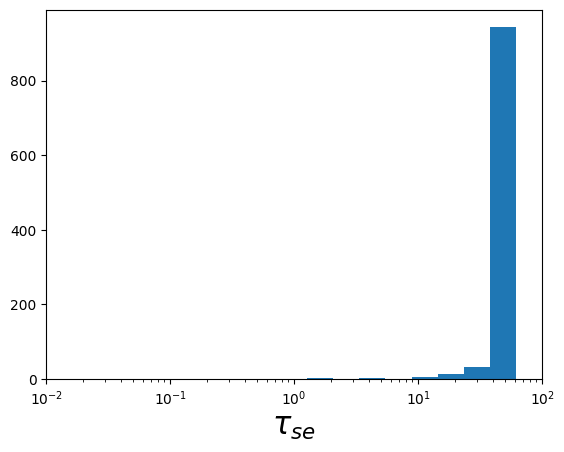

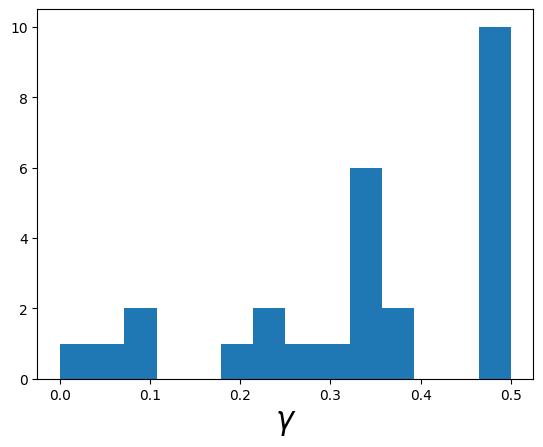

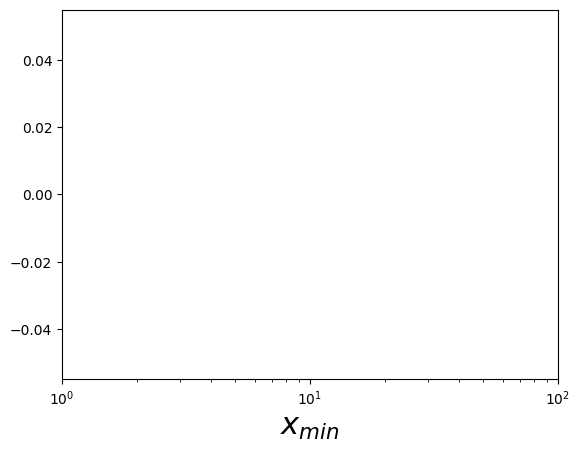

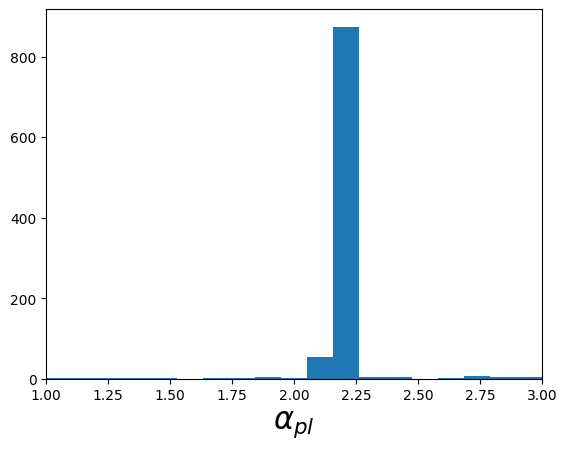

In [86]:
used_gen = last_gen
plt.figure()
plt.hist(last_gen[:,0],bins=np.linspace(0,10,20),label='last gen')
plt.hist(zeroth_gen[:,0],bins=np.linspace(0,10,20),alpha=0.5,label='0th gen')
plt.hist(first_gen[:,0],bins=np.linspace(0,10,20),alpha=0.5,label='1st gen')
plt.legend()
plt.yscale('log')
#plt.xscale('log')
#plt.xlim(3,3.2)
#plt.xlim(2.95,3.25)
plt.xlabel(r'$\tau_i$',size=22)
plt.figure()
plt.hist(used_gen[:,1],bins=np.linspace(0,20,20))
#plt.xscale('log')
plt.xlim(0,20)
plt.xlabel(r'$\tau_d$',size=22)
plt.figure()
plt.hist(used_gen[:,2],bins=np.linspace(0,0.2,20))
#plt.xscale('log')
plt.xlim(0,0.2)
plt.xlabel(r'$\tau_r$',size=22)
plt.figure()
plt.hist(used_gen[:,3],bins=np.logspace(-2,2,20))
plt.xscale('log')
plt.xlim(0.01,100)
plt.xlabel(r'$\tau_{se}$',size=22)

plt.figure()
plt.hist(used_gen[:,4],bins=np.linspace(0,0.5,15))
#plt.xscale('log')
#plt.xlim(1,1e4)
plt.xlabel(r'$\gamma$',size=22)


plt.figure()
plt.hist(used_gen[:,5],bins=np.logspace(0,2,20))
plt.xscale('log')
plt.xlim(1,100)
plt.xlabel(r'$x_{min}$',size=22)

plt.figure()
plt.hist(used_gen[:,6],bins=np.linspace(1,3,20))
#plt.xscale('log')
plt.xlim(1,3)
plt.xlabel(r'$\alpha_{pl}$',size=22)


#plt.hist(to_use[:,4],bins=np.logspace(np.min()))

avg_tau_i        = np.zeros(num_generations+1)
std_tau_i        = np.zeros(num_generations+1)
#
avg_tau_d       = np.zeros(num_generations+1)
std_tau_d      = np.zeros(num_generations+1)
#
avg_alpha     = np.zeros(num_generations+1)
std_alpha     = np.zeros(num_generations+1)
#
avg_tau_se    = np.zeros(num_generations+1)
std_tau_se    = np.zeros(num_generations+1)
#
avg_gamma= np.zeros(num_generations+1)
std_gamma= np.zeros(num_generations+1)
#
avg_x_min    = np.zeros(num_generations+1)
std_x_min   = np.zeros(num_generations+1)
#
avg_alpha_pl   = np.zeros(num_generations+1)
std_alpha_pl   = np.zeros(num_generations+1)
#

for i in range(num_generations+1):
    avg_tau_i[i]        = np.mean( df_all_gen[ 'tau_i'        ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_tau_i[i]        = np.std(  df_all_gen[ 'tau_i'        ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
    avg_tau_d[i]       = np.mean( df_all_gen[ 'tau_d'       ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_tau_d[i]       = np.std(  df_all_gen[ 'tau_d'       ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
    avg_alpha[i]     = np.mean( df_all_gen[ 'tau_r'     ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_alpha[i]     = np.std(  df_all_gen[ 'tau_r'     ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
    avg_tau_se[i]    = np.mean( df_all_gen[ 'tau_se'    ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_tau_se[i]    = np.std(  df_all_gen[ 'tau_se'    ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
    avg_gamma[i]= np.mean( df_all_gen[ 'gamma'    ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_gamma[i]= np.std(  df_all_gen[ 'gamma'    ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
    
    avg_x_min[i]    = np.mean( df_all_gen[ 'x_min'    ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_x_min[i]    = np.std(  df_all_gen[ 'x_min'    ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
    avg_alpha_pl[i]   = np.mean( df_all_gen[ 'alpha_pl'   ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    std_alpha_pl[i]   = np.std(  df_all_gen[ 'alpha_pl'   ].to_numpy()[i*sol_per_pop:(i+1)*sol_per_pop] )
    #
fig, ax = plt.subplots(3, 3, figsize=(24,16))   
################################################################################
# PLOT 1
################################################################################
ax[0,0].errorbar(np.arange(num_generations+1), avg_tau_i, yerr=std_tau_i/np.sqrt(sol_per_pop), 
                 ls='-', lw=2, c='b', ecolor='r')
#ax[0,0].set_ylim(0.80, 1.7)
ax[0,0].set_xlabel('Epochs', size=25)
ax[0,0].set_ylabel(r'$\tau_i$', size=25)
#ax[0,0].set_title(r'$0.8 \leq q \leq 1.7$', size=25)
################################################################################
# PLOT 2
################################################################################
ax[0,1].errorbar(np.arange(num_generations+1), avg_tau_d, yerr=std_tau_d/np.sqrt(sol_per_pop), 
                 ls='-', lw=2, c='b', ecolor='r')
#ax[0,1].set_ylim(0.80, 1.7)
ax[0,1].set_xlabel('Epochs', size=25)
ax[0,1].set_ylabel(r'$\tau_d$', size=25)
#ax[0,1].set_title(r'$0.8 \leq a \leq 1.7$', size=25)
################################################################################
# PLOT 3
################################################################################
ax[0,2].errorbar(np.arange(num_generations+1), avg_alpha, yerr=std_alpha/np.sqrt(sol_per_pop), 
                 ls='-', lw=2, c='b', ecolor='r')
#ax[0,2].set_ylim(1, 15)
ax[0,2].set_xlabel('Epochs', size=25)
ax[0,2].set_ylabel(r'$\tau_r$', size=25)
#ax[0,2].set_title(r'$1 \leq \alpha \leq 15$', size=25)
################################################################################
# PLOT 4
################################################################################
ax[1,0].errorbar(np.arange(num_generations+1), avg_tau_se, yerr=std_tau_se/np.sqrt(sol_per_pop), 
                 ls='-', lw=2, c='b', ecolor='r')
#ax[1,0].set_ylim(-1.5, -0.30*(1+1.e-6))
ax[1,0].set_xlabel('Epochs', size=25)
ax[1,0].set_ylabel(r'$\tau_{se}$', size=25)
#ax[1,0].set_title(r'$-1.5 \leq k \leq -0.3$', size=25)
################################################################################
# PLOT 5
################################################################################


ax[1,1].errorbar(np.arange(num_generations+1), avg_gamma, yerr=std_gamma/np.sqrt(sol_per_pop),ls='-', lw=2, c='b', ecolor='r')
#ax[1,1].set_ylim(0, 0.50)
ax[1,1].set_xlabel('Epochs', size=25)
ax[1,1].set_ylabel(r'$\gamma$', size=25)
################################################################################
# PLOT 6
################################################################################
ax[1,2].errorbar(np.arange(num_generations+1), avg_x_min, yerr=std_x_min/np.sqrt(sol_per_pop), 
                 ls='-', lw=2, c='b', ecolor='r')
#ax[1,2].set_ylim(0, 0.30)
ax[1,2].set_xlabel('Epochs', size=25)
ax[1,2].set_ylabel(r'$x_{min}$', size=25)
#ax[1,2].set_title(r'$0 \leq t_0 \leq 0.3$', size=25)
################################################################################
# PLOT 6
################################################################################
ax[2,2].errorbar(np.arange(num_generations+1), avg_alpha_pl, yerr=std_alpha_pl/np.sqrt(sol_per_pop), 
                  ls='-', lw=2, c='b', ecolor='r')
# #ax[1,2].set_ylim(1.e-2, 0.064*(1-1.e-6))
ax[2,2].set_xlabel('Epochs', size=25)
ax[2,2].set_ylabel(r'$\alpha_{pl}$', size=25)
#ax[1,2].set_yscale('log')
#ax[1,2].set_title(r'$0.01 \leq norm_A \leq 0.064$', size=25)
################################################################################
################################################################################
#ax[3,2].set_visible(False)
################################################################################
ax[0,0].tick_params(axis='both', labelsize=18)
ax[0,1].tick_params(axis='both', labelsize=18)
ax[0,2].tick_params(axis='both', labelsize=18)
ax[1,0].tick_params(axis='both', labelsize=18)
ax[1,1].tick_params(axis='both', labelsize=18)
ax[1,2].tick_params(axis='both', labelsize=18)
#ax[2,0].tick_params(axis='both', labelsize=15)
#ax[2,1].tick_params(axis='both', labelsize=15)
#ax[2,2].tick_params(axis='both', labelsize=15)
#ax[3,0].tick_params(axis='both', labelsize=15)
#ax[3,1].tick_params(axis='both', labelsize=15)
#fig.suptitle('Evolution of the (avg. of) the 11 parameters for v'+str(folder_number), size=30)
fig.suptitle('Evolution of the (avg. of) the parameters', size=30,y=1.01)
fig.tight_layout()
plt.savefig('/astrodata/romain/sde_GA/geneticgrbs_v2/genetic_algorithm/'+folder_number+'/fig-params.pdf')
plt.show()



# 4. Real vs. Fake

In [17]:
ax[1,1]

<Axes: xlabel='Epochs', ylabel='$\\gamma$'>

<ErrorbarContainer object of 3 artists>

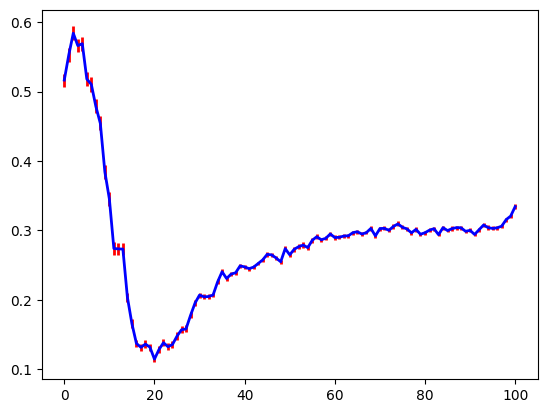

In [18]:
plt.errorbar(np.arange(num_generations+1), avg_gamma, yerr=std_gamma/np.sqrt(sol_per_pop),ls='-', lw=2, c='b', ecolor='r')

In [19]:
path_simulati_OLD = '/Users/lorenzo/Documents/UNIVERSITA/Astrophysics/PYTHON/GRBs/lc_pulse_avalanche/simulations/batse-fig/'
path_simulati     = '/Users/lorenzo/Documents/UNIVERSITA/Astrophysics/PYTHON/GRBs/lc_pulse_avalanche/simulations/batse-v35/'
path_reali        = '/Users/lorenzo/Documents/UNIVERSITA/Astrophysics/PYTHON/DATA/CGRO_BATSE/'

### SIMULATED 
# Single peak:        lc
# Double peak:        lc
# Moderately complex: lc
# Erratic:            lc

### SIMULATED OLD
# Single peak:        lc2
# Double peak:        lc32
# Moderately complex: lc0
# Erratic:            lc34

### REAL
# Single peak:        00469
# Double peak:        00143
# Moderately complex: 00394 
# Erratic:            01156  

FileNotFoundError: /Users/lorenzo/Documents/UNIVERSITA/Astrophysics/PYTHON/DATA/CGRO_BATSE/06375_all_bs.out not found.

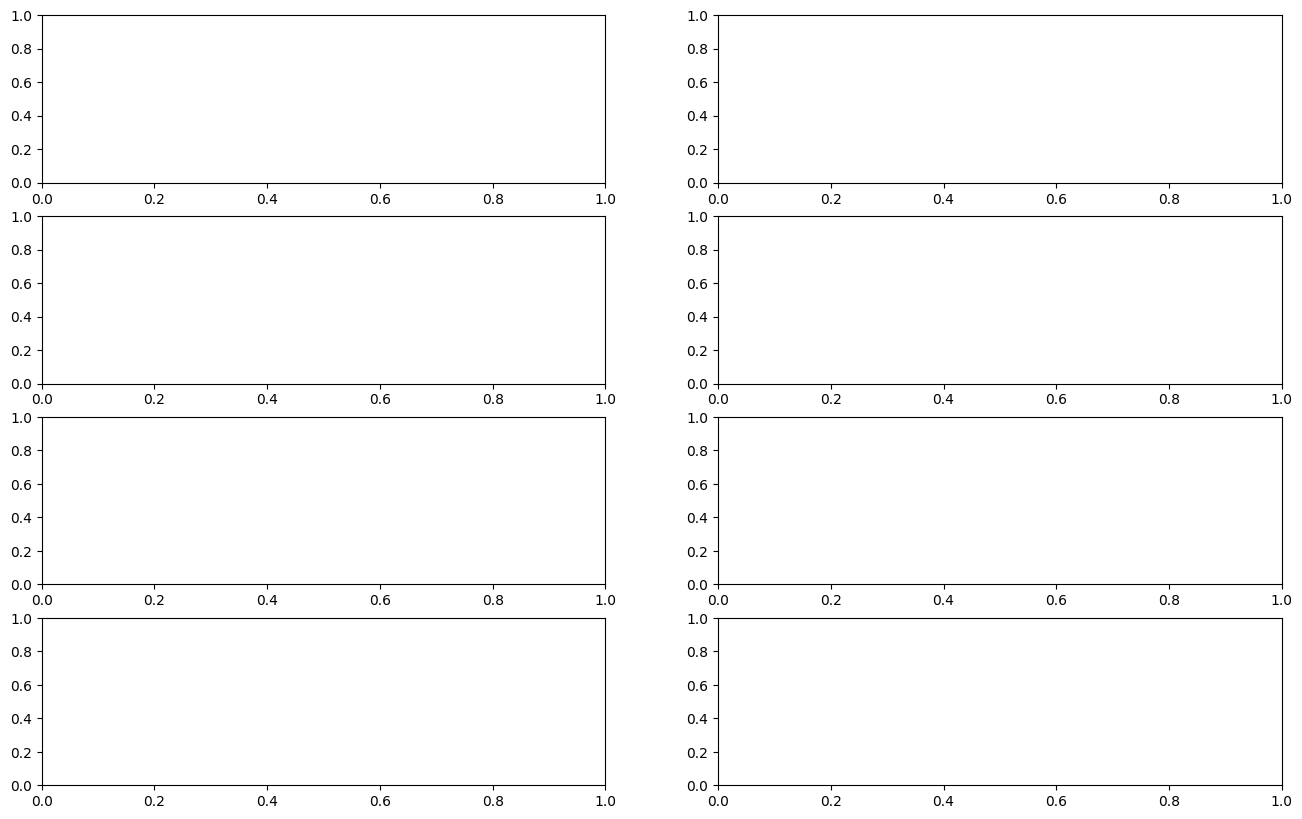

In [20]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize=(16,10))

################################################################################
# REAL
################################################################################
x,y,yerr = np.loadtxt(path_reali+'06375_all_bs.out', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_reali+'00469_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[0,0].step(x,y, color = 'black', lw=1, where = 'post')
ax[0,0].set_xlim(-1.5,18)
ax[0,0].set_ylim(-70,230)
ax[0,0].set_ylabel('counts/64 ms', size=14)
ax[0,0].set_title('\emph{Real} BATSE GRBs', size=20)
max_pos = ax[0,0].get_xlim()[1]
max_y = np.max(y)
ax[0,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[0,0].text(15, 100, '\#06375', fontsize = 20, color = 'black')
ax[0,0].xaxis.set_tick_params(labelsize=12)
ax[0,0].yaxis.set_tick_params(labelsize=12)

x,y,yerr = np.loadtxt(path_reali+'02083_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[1,0].step(x,y, color = 'black', lw=0.9, where = 'post')
ax[1,0].set_xlim(-10,50)
ax[1,0].set_ylabel('counts/64 ms', size=14)
max_pos = ax[1,0].get_xlim()[1]
max_y = np.max(y)
ax[1,0].errorbar(max_pos - 0.1 * max_pos,  max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[1,0].text(41, 6000, '\#02083', fontsize = 20, color = 'black')
ax[1,0].xaxis.set_tick_params(labelsize=12)
ax[1,0].yaxis.set_tick_params(labelsize=12)

x,y,yerr = np.loadtxt(path_reali+'01157_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[2,0].step(x,y, color = 'black', lw=0.6, where = 'post')
ax[2,0].set_xlim(-5,65)
ax[2,0].set_ylabel('counts/64 ms', size=14)
max_pos = ax[2,0].get_xlim()[1]
max_y = np.max(y)
ax[2,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[2,0].text(54.5, 1500, '\#01157', fontsize = 20, color = 'black')
ax[2,0].xaxis.set_tick_params(labelsize=12)
ax[2,0].yaxis.set_tick_params(labelsize=12)

x,y,yerr = np.loadtxt(path_reali+'02831_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[3,0].step(x,y, color = 'black', lw=0.6, where = 'post')
ax[3,0].set_xlim(-1,240)
ax[3,0].set_ylabel('counts/64 ms', size=14)
ax[3,0].set_xlabel('Time since trigger [s]', size=20)
max_pos = ax[3,0].get_xlim()[1]
max_y = np.max(y)
ax[3,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[3,0].text(205, 5500, '\#02831', fontsize = 20, color = 'black')
ax[3,0].xaxis.set_tick_params(labelsize=12)
ax[3,0].yaxis.set_tick_params(labelsize=12)

################################################################################
#SIMULATED
################################################################################

x,y,yerr = np.loadtxt(path_simulati+'lc10.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc2.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[0,1].step(x,y, color = 'black', lw=1, where = 'post')
ax[0,1].set_xlim(0.5,20)
ax[0,1].set_title('\emph{Simulated} BATSE GRBs', size=20)
max_pos = ax[0,1].get_xlim()[1]
max_y = np.max(y)
ax[0,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[0,1].xaxis.set_tick_params(labelsize=12)
ax[0,1].yaxis.set_tick_params(labelsize=12)

x,y,yerr = np.loadtxt(path_simulati+'lc41.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati+'lc22.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc32.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[1,1].step(x,y, color = 'black', lw=0.35, where = 'post')
ax[1,1].set_xlim(-10,150)
max_pos = ax[1,1].get_xlim()[1]
max_y = np.max(y)
ax[1,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[1,1].xaxis.set_tick_params(labelsize=12)
ax[1,1].yaxis.set_tick_params(labelsize=12)

x,y,yerr = np.loadtxt(path_simulati+'lc34.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc0.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[2,1].step(x,y, color = 'black', lw=0.35, where = 'post')
ax[2,1].set_xlim(-5,100)
max_pos = ax[2,1].get_xlim()[1]
max_y = np.max(y)
ax[2,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[2,1].xaxis.set_tick_params(labelsize=12)
ax[2,1].yaxis.set_tick_params(labelsize=12)

x,y,yerr = np.loadtxt(path_simulati+'lc18.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc34.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[3,1].step(x,y, color = 'black', lw=0.35, where = 'post')
ax[3,1].set_xlim(-5,240)
ax[3,1].set_xlabel('Time since trigger [s]', size=20)
max_pos = ax[3,1].get_xlim()[1]
max_y = np.max(y)
ax[3,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'black', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[3,1].xaxis.set_tick_params(labelsize=12)
ax[3,1].yaxis.set_tick_params(labelsize=12)

################################################################################
################################################################################

plt.tight_layout()
plt.savefig('fig-real-fake-paper.pdf')
plt.show()

In [ ]:
import matplotlib.patches as patches

#true_label = True
true_label = False

fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize=(16,10))

################################################################################
# REAL
################################################################################
x,y,yerr = np.loadtxt(path_reali+'06375_all_bs.out', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_reali+'00469_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[0,0].step(x,y, color = 'blue', lw=1, where = 'post')
ax[0,0].set_xlim(-1.5,18)
ax[0,0].set_ylim(-70,230)
ax[0,0].set_ylabel('counts/64 ms', size=14)
max_pos = ax[0,0].get_xlim()[1]
max_y = np.max(y)
ax[0,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
if true_label:
    ax[0,0].text(15, 100, '\#06375', fontsize = 20, color = 'black')
ax[0,0].xaxis.set_tick_params(labelsize=12)
ax[0,0].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[0,0].add_patch(patches.Rectangle(xy=(ax[0,0].get_xlim()[0], ax[0,0].get_ylim()[0]),
                                        width=ax[0,0].get_xlim()[1]-ax[0,0].get_xlim()[0],
                                        height=ax[0,0].get_ylim()[1]-ax[0,0].get_ylim()[0], 
                                        linewidth=12, color='lime', fill=False))

x,y,yerr = np.loadtxt(path_reali+'02083_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[1,1].step(x,y, color = 'blue', lw=0.9, where = 'post')
ax[1,1].set_xlim(-10,50)
ax[1,0].set_ylabel('counts/64 ms', size=14)
max_pos = ax[1,1].get_xlim()[1]
max_y = np.max(y)
ax[1,1].errorbar(max_pos - 0.1 * max_pos,  max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
if true_label:
    ax[1,1].text(41, 6000, '\#02083', fontsize = 20, color = 'black')
ax[1,1].xaxis.set_tick_params(labelsize=12)
ax[1,1].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[1,1].add_patch(patches.Rectangle(xy=(ax[1,1].get_xlim()[0], ax[1,1].get_ylim()[0]),
                                        width=ax[1,1].get_xlim()[1]-ax[1,1].get_xlim()[0],
                                        height=ax[1,1].get_ylim()[1]-ax[1,1].get_ylim()[0], 
                                        linewidth=12, color='lime', fill=False))

x,y,yerr = np.loadtxt(path_reali+'01157_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[2,0].step(x,y, color = 'blue', lw=0.6, where = 'post')
ax[2,0].set_xlim(-5,65)
ax[2,0].set_ylabel('counts/64 ms', size=14)
max_pos = ax[2,0].get_xlim()[1]
max_y = np.max(y)
ax[2,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
if true_label:
    ax[2,0].text(54.5, 1500, '\#01157', fontsize = 20, color = 'black')
ax[2,0].xaxis.set_tick_params(labelsize=12)
ax[2,0].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[2,0].add_patch(patches.Rectangle(xy=(ax[2,0].get_xlim()[0], ax[2,0].get_ylim()[0]),
                                        width=ax[2,0].get_xlim()[1]-ax[2,0].get_xlim()[0],
                                        height=ax[2,0].get_ylim()[1]-ax[2,0].get_ylim()[0], 
                                        linewidth=12, color='lime', fill=False))

x,y,yerr = np.loadtxt(path_reali+'02831_all_bs.out', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[3,1].step(x,y, color = 'blue', lw=0.6, where = 'post')
ax[3,1].set_xlim(-1,240)
ax[3,0].set_ylabel('counts/64 ms', size=14)
ax[3,1].set_xlabel('Time since trigger [s]', size=20)
max_pos = ax[3,1].get_xlim()[1]
max_y = np.max(y)
ax[3,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
if true_label:
    ax[3,1].text(205, 5500, '\#02831', fontsize = 20, color = 'black')
ax[3,1].xaxis.set_tick_params(labelsize=12)
ax[3,1].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[3,1].add_patch(patches.Rectangle(xy=(ax[3,1].get_xlim()[0], ax[3,1].get_ylim()[0]),
                                        width=ax[3,1].get_xlim()[1]-ax[3,1].get_xlim()[0],
                                        height=ax[3,1].get_ylim()[1]-ax[3,1].get_ylim()[0], 
                                        linewidth=12, color='lime', fill=False))

################################################################################
#SIMULATED
################################################################################

x,y,yerr = np.loadtxt(path_simulati+'lc10.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc2.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[0,1].step(x,y, color = 'blue', lw=1, where = 'post')
ax[0,1].set_xlim(0.5,20)
max_pos = ax[0,1].get_xlim()[1]
max_y = np.max(y)
ax[0,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[0,1].xaxis.set_tick_params(labelsize=12)
ax[0,1].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[0,1].add_patch(patches.Rectangle(xy=(ax[0,1].get_xlim()[0], ax[0,1].get_ylim()[0]),
                                        width=ax[0,1].get_xlim()[1]-ax[0,1].get_xlim()[0],
                                        height=ax[0,1].get_ylim()[1]-ax[0,1].get_ylim()[0], 
                                        linewidth=12, color='red', fill=False))

x,y,yerr = np.loadtxt(path_simulati+'lc41.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati+'lc22.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc32.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[1,0].step(x,y, color = 'blue', lw=0.35, where = 'post')
ax[1,0].set_xlim(-10,150)
max_pos = ax[1,0].get_xlim()[1]
max_y = np.max(y)
ax[1,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[1,0].xaxis.set_tick_params(labelsize=12)
ax[1,0].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[1,0].add_patch(patches.Rectangle(xy=(ax[1,0].get_xlim()[0], ax[1,0].get_ylim()[0]),
                                        width=ax[1,0].get_xlim()[1]-ax[1,0].get_xlim()[0],
                                        height=ax[1,0].get_ylim()[1]-ax[1,0].get_ylim()[0], 
                                        linewidth=12, color='red', fill=False))

x,y,yerr = np.loadtxt(path_simulati+'lc34.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc0.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[2,1].step(x,y, color = 'blue', lw=0.35, where = 'post')
ax[2,1].set_xlim(-5,100)
max_pos = ax[2,1].get_xlim()[1]
max_y = np.max(y)
ax[2,1].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[2,1].xaxis.set_tick_params(labelsize=12)
ax[2,1].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[2,1].add_patch(patches.Rectangle(xy=(ax[2,1].get_xlim()[0], ax[2,1].get_ylim()[0]),
                                        width=ax[2,1].get_xlim()[1]-ax[2,1].get_xlim()[0],
                                        height=ax[2,1].get_ylim()[1]-ax[2,1].get_ylim()[0], 
                                        linewidth=12, color='red', fill=False))

x,y,yerr = np.loadtxt(path_simulati+'lc18.txt', usecols = (0,1,2), unpack = True)
#x,y,yerr = np.loadtxt(path_simulati_OLD+'lc34.txt', usecols = (0,1,2), unpack = True)
repr_error = np.mean(yerr)
ax[3,0].step(x,y, color = 'blue', lw=0.35, where = 'post')
ax[3,0].set_xlim(-5,240)
ax[3,0].set_xlabel('Time since trigger [s]', size=20)
max_pos = ax[3,0].get_xlim()[1]
max_y = np.max(y)
ax[3,0].errorbar(max_pos - 0.1 * max_pos, max_y - 0.1 * max_y, yerr = repr_error, marker = None, color = 'blue', lw = 0.5, fmt='o', markersize = 0, capsize = 1)
ax[3,0].xaxis.set_tick_params(labelsize=12)
ax[3,0].yaxis.set_tick_params(labelsize=12)
if true_label:
    ax[3,0].add_patch(patches.Rectangle(xy=(ax[3,0].get_xlim()[0], ax[3,0].get_ylim()[0]),
                                        width=ax[3,0].get_xlim()[1]-ax[3,0].get_xlim()[0],
                                        height=ax[3,0].get_ylim()[1]-ax[3,0].get_ylim()[0], 
                                        linewidth=12, color='red', fill=False))

################################################################################
################################################################################

plt.tight_layout()
if true_label:
    plt.savefig('fig-real-fake-2.pdf')
else:
    plt.savefig('fig-real-fake-1.pdf')
plt.show()

In [ ]:
path_simulati = '/Users/lorenzo/Documents/UNIVERSITA/Astrophysics/PYTHON/GRBs/lc_pulse_avalanche/simulations/batse-v35/'
for i in range(40,42):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    x,y,yerr = np.loadtxt(path_simulati+'lc'+str(i)+'.txt', usecols = (0,1,2), unpack = True)
    ax.step(x,y, color = 'black', lw=0.5, where = 'post', label=str(i))
    ax.set_xlim(-10,150)
    ax.set_xlabel('Time since trigger [s]', size=20)
    plt.legend()
    plt.show()

In [ ]:
files   = os.listdir(path_reali)
real_lc = [file for file in files if file.endswith('all_bs.out')]

for i in range(130,150):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    x,y,yerr = np.loadtxt(path_reali+real_lc[i], usecols = (0,1,2), unpack = True)
    ax.step(x,y, color = 'black', lw=1, where = 'post', label=real_lc[i])
    ax.set_xlim(-10,200)
    plt.legend()
    plt.show()

# 5. $k$ factors

In [ ]:
k_batse = np.loadtxt('../lc_pulse_avalanche/log10_fluence_over_counts_CGRO_BATSE.txt')
k_swift = np.loadtxt('../lc_pulse_avalanche/log10_fluence_over_counts_Swift_BAT.txt')
k_fermi = np.loadtxt('../lc_pulse_avalanche/log10_fluence_over_counts_Fermi_GBM.txt')

fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharey='row', facecolor='w')

### Plot 1
ax[0].hist(k_batse, bins=30, density=False, ec='black', label='BATSE')
ax[0].set_xticks([-10.5, -10.0, -9.5, -9.0])
ax[0].xaxis.set_tick_params(length=4, labelsize=12)
ax[0].yaxis.set_tick_params(length=4, labelsize=12)
ax[0].set_xlabel(r'$k$', size=18)
ax[0].set_ylabel(r'No. of GRBs', size=18)
ax[0].set_title(r'$CGRO$/BATSE', size=20)
ax[0].grid(False)
# ax[0].legend(fontsize=20)
### Plot 2
ax[1].hist(k_swift, bins=30, density=False, ec='black', label='Swift')
ax[1].set_xticks([-6.5, -6.0, -5.5])
ax[1].xaxis.set_tick_params(length=4, labelsize=12)
ax[1].yaxis.set_tick_params(length=4, labelsize=12)
ax[1].set_xlabel(r'$k$', size=18)
ax[1].set_title(r'$Swift$/BAT', size=20)
ax[1].grid(False)
# ax[1].legend(fontsize=20)
### Plot 3
ax[2].hist(k_fermi, bins=30, density=False, ec='black', label='Fermi')
ax[2].xaxis.set_tick_params(length=4, labelsize=12)
ax[2].yaxis.set_tick_params(length=4, labelsize=12)
ax[2].set_xlabel(r'$k$', size=18)
ax[2].set_title(r'$FERMI$/GBM', size=20)
ax[2].grid(False)
# ax[2].legend(fontsize=20)

###
plt.tight_layout()
plt.savefig('k_factor_distributions.pdf', format='pdf')
plt.show()

# DEBUG

In [ ]:
################################################################################
# MAKE PLOT
################################################################################

ndim, nsamples = 5, 10000
samples = np.random.randn(ndim * nsamples).reshape([nsamples, ndim])
figure = corner.corner(
    samples,
    labels=[
        r"$x$",
        r"$y$",
        r"$\log \alpha_1$",
        r"$\log \alpha_2$",
        r"$\Gamma \, [\mathrm{parsec}]$",
    ],
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.39, 0.86], # 1,2 sigmas 
    show_titles=True,
    fill_contours=False,
    #smooth=0.1,
    #plot_density=False,
    #plot_datapoints=False,
    #show_titles=True,
    #max_n_ticks=3,
    #title_fmt=".2E",
    label_kwargs={"fontsize": 16},
    title_kwargs={"fontsize": 16},
)
plt.show()

In [ ]:
################################################################################
# SMOOTHLY-BROKEN POWER LAW
################################################################################

def sbpl(x, a_1, a_2, x_0, x_m):
    s = 20
    return (((x_m/x_0)**(a_1*s) + (x_m/x_0)**(a_2*s))/((x/x_0)**(a_1*s) + (x/x_0)**(a_2*s)))**(1/s)

# a_1 = 0.8
# a_2 = 1.5
# x_0 = 1e-6
# x_m = 1e-8
# x_M = 1e-4

# x = np.linspace(x_m, x_M, 512)
# y = sbpl(x, a_1, a_2, x_0, x_m)

# log_x = np.log10(x)
# log_y = np.log10(y)

# fig, ax = plt.subplots(1, 1)
# ax.plot(log_x, log_y, lw=3)
# plt.show()